## Análisis exploratorio de datos

Se proporcionan dos archivos .csv con datos:

el dataset 1  contiene los siguientes datos:

-  __company_name__: nombre de la empresa de taxis
- __trips_amount__: el número de viajes de cada compañía de taxis el 15 y 16 de noviembre de 2017. 

El dataset 2 contiene:

- __dropoff_location_name__: barrios de Chicago donde finalizaron los viajes
- __average_trips__: el promedio de viajes que terminaron en cada barrio en noviembre de 2017.

In [1]:
# Importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats as st

In [2]:
# Ajustes globales. 

pd.set_option("display.max_rows", 70)  # muestra hasta 70 filas
sns.set_style("whitegrid") # Mostrar grid en gráficas

In [3]:
# Importar pimer dataset, viajes por compañía

df_trips = pd.read_csv(r'/datasets/project_sql_result_01.csv')

In [4]:
# Mostrar información básica del dataframe

df_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


Los tipos de datos son correctos y no hay faltantes. Al ser 64 registros podemos inspeccionarlos todos fácilmente. Pero antes busquemos duplicados.

In [5]:
# Encontrar compañías duplicadas

df_trips['company_name'].duplicated().sum()

0

No hay duplicados. Se inspeccionan los datos.

In [6]:
# Mostrar datos en orden de cantidad de viajes.

df_trips.sort_values(by='trips_amount', ascending = False)

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


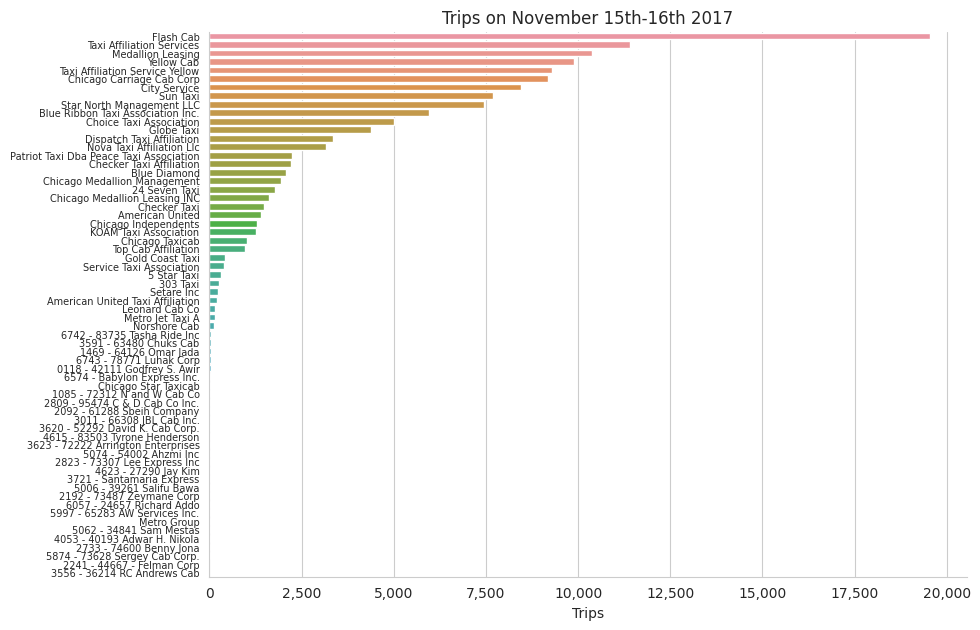

In [7]:
# Gráfica de número de viajes por empresa de taxis

g=sns.catplot(data = df_trips,y = 'company_name', x= 'trips_amount',kind = 'bar', height = 6, aspect = 16/9)
g.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
g.ax.tick_params(axis="y", labelsize=7)
plt.title("Trips on November 15th-16th 2017")
plt.xlabel("Trips")
plt.ylabel("")
plt.show()


Aquí se observa que la tabla incluye taxistas que aparentemente no son parte de compañías (caracterizados por tener el patrón #### - ##### antes del nombre) y que estos aportan pocos viajes respecto al total. Veamos el resultado al excluirlos.

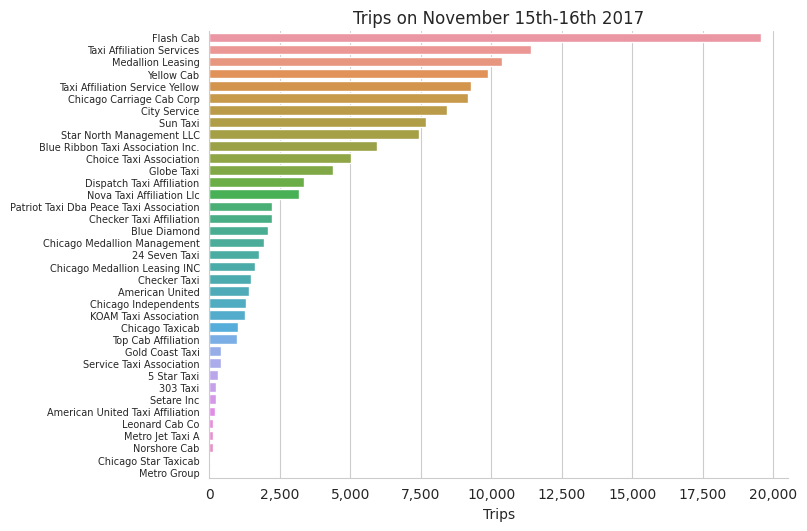

In [8]:
# Gráfica filtrando.
df_trips_selected = df_trips.loc[~df_trips['company_name'].str.contains('-')].copy()
g=sns.catplot(data = df_trips_selected,y = 'company_name', x= 'trips_amount',kind = 'bar', aspect = 16/9)
g.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
g.ax.tick_params(axis="y", labelsize=7)
plt.title("Trips on November 15th-16th 2017")
plt.xlabel("Trips")
plt.ylabel("")
plt.show()


Ahora se calcula la cuota de mercado que estas compañías tienen.

In [9]:
df_trips_selected['trips_%'] = df_trips_selected['trips_amount']/df_trips_selected['trips_amount'].sum()*100
df_trips_selected['cum_trips_%']= df_trips_selected['trips_%'].cumsum()
df_trips_selected

,company_name,trips_amount,trips_%,cum_trips_%
0,Flash Cab,19558,14.298351,14.298351
1,Taxi Affiliation Services,11422,8.350331,22.648682
2,Medallion Leasing,10367,7.579047,30.227730
3,Yellow Cab,9888,7.228863,37.456592
4,Taxi Affiliation Service Yellow,9299,6.798260,44.254853
5,Chicago Carriage Cab Corp,9181,6.711993,50.966846
6,City Service,8448,6.176116,57.142962
7,Sun Taxi,7701,5.630003,62.772965
8,Star North Management LLC,7455,5.450159,68.223124
9,Blue Ribbon Taxi Association Inc.,5953,4.352085,72.575209


5 compaañías acaparan el 50% de los viajes. 10 compañías el 75%. Además considerar que __Taxi Affiliation Services__ y __Taxi Affiliation Services Yellow__ pueden en realidad tratarse de la misma compañía.

A continuación se analiza el segundo conjunto de datos.

In [10]:
# Importar segundo datasets, viajes por punto de destino.

df_chicago_trips = pd.read_csv(r'/datasets/project_sql_result_04.csv')

In [11]:
# Mostrar información básica del dataframe

df_chicago_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


Los tipos de datos son correctos y no hay faltantes.

In [12]:
# Contar registros duplicados

df_chicago_trips['dropoff_location_name'].duplicated().sum()

0

No hay duplicados. A continuación se identifican los 10 principales barrios en términos de finalización del recorrido

In [13]:
top_neighborhoods = df_chicago_trips.sort_values(by = 'average_trips', ascending = False).reset_index(drop = True)[:10]
#top_neighborhoods = df_chicago_trips.value_counts()
top_neighborhoods

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


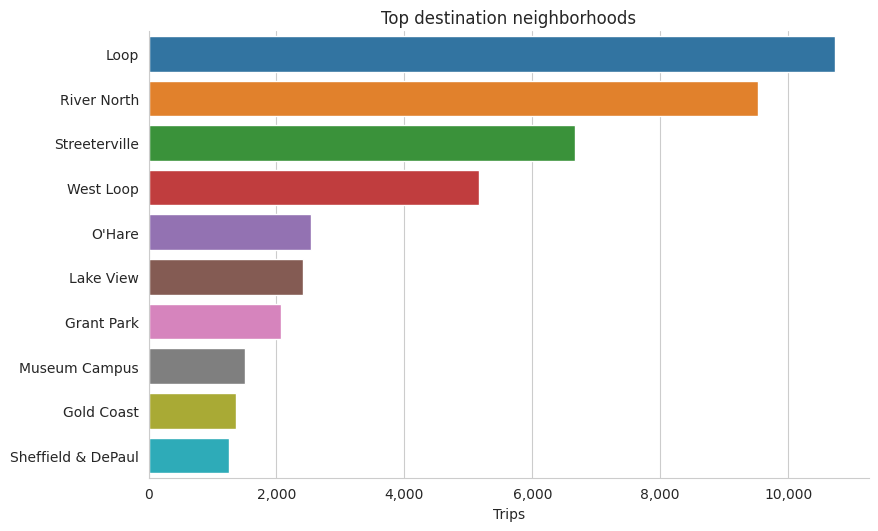

In [14]:
# Gráfica de los 10 principales barrios

g=sns.catplot(data = top_neighborhoods,y = 'dropoff_location_name', x= 'average_trips',kind = 'bar', aspect = 16/9)
plt.title("Top destination neighborhoods")
g.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xlabel("Trips")
plt.ylabel("")

plt.show()

De manera similar se calculan los porcentajes respecto al total de viajes.

In [15]:
top_neighborhoods['average_%']= top_neighborhoods['average_trips']/df_chicago_trips['average_trips'].sum()*100
top_neighborhoods['cum_average_%']= top_neighborhoods['average_%'].cumsum()
top_neighborhoods

,dropoff_location_name,average_trips,average_%,cum_average_%
0,Loop,10727.466667,19.021798,19.021798
1,River North,9523.666667,16.887236,35.909034
2,Streeterville,6664.666667,11.817696,47.726730
3,West Loop,5163.666667,9.156143,56.882874
4,O'Hare,2546.900000,4.516128,61.399002
5,Lake View,2420.966667,4.292825,65.691827
6,Grant Park,2068.533333,3.667895,69.359723
7,Museum Campus,1510.000000,2.677511,72.037234
8,Gold Coast,1364.233333,2.419040,74.456274
9,Sheffield & DePaul,1259.766667,2.233801,76.690075


Estos 10 destinos representan poco más del 75% de todos los viajes que se hicieron durante el mes. Y los primeros 4 acaparan el 50% respectivamente.

## Prueba de hipótesis

Se proporciona un .csv con los resultados de una consulta previamente realizada. Contiene datos sobre viajes desde el Loop hasta el Aeropuerto Internacional O'Hare. 
Estos son los valores de campo de la tabla:

- __start_ts__: fecha y hora de la recogida
- __weather_conditions__: condiciones climáticas en el momento en el que comenzó el viaje
- __duration_seconds__: duración del viaje en segundos

El interés aquí está en hacer la prueba de la siguiente hipotesis:

> La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos.

Esta prueba es comparar las medias de dos poblaciones estadísticas diferentes. 
La hipótesis nula es que ambas medias poblacionales son iguales; La hipotesis alterna es que no son iguales.

No se asumirá que las varianzas son iguales, lo que en caso de rechazar la hipótesis nula asegura que también sería rechazada bajo ese supuesto.

Al tratarse de una situación no tan controlada se decide establecer un nivel de significación $\alpha= 5\%$, lo que es práctica común.

In [16]:
df = pd.read_csv(r'/datasets/project_sql_result_07.csv')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [18]:
# Convertir a datetime

df['start_ts']=pd.to_datetime(df['start_ts'])

In [19]:
# Enriquecer el dataframe

df['sabado'] = df['start_ts'].dt.weekday == 5
df['lluvioso'] = df['weather_conditions'] == 'Bad'

In [20]:
# Filtrar sábados lluviosos y mostrar estadísticas sobre la duración de los viajes

df_lluvioso = df[df['sabado'] & df['lluvioso']]
df_lluvioso['duration_seconds'].describe()

count     180.000000
mean     2427.205556
std       721.314138
min       480.000000
25%      1962.000000
50%      2540.000000
75%      2928.000000
max      4980.000000
Name: duration_seconds, dtype: float64

In [21]:
# De hecho todos los registros son de días sábado

df['start_ts'].dt.weekday.value_counts()

5    1068
Name: start_ts, dtype: int64

In [22]:
# Filtrar sábados no lluviosos y mostrar estadísticas sobre la duración de los viajes

df_no_lluvioso = df[~(df['sabado'] & df['lluvioso'])]
df_no_lluvioso['duration_seconds'].describe()

count     888.000000
mean     1999.675676
std       759.198268
min         0.000000
25%      1389.750000
50%      1800.000000
75%      2460.000000
max      7440.000000
Name: duration_seconds, dtype: float64

A ojo parece que la media realmente es mayor para los días lluviosos, por 400 segundos. Se muestra un boxplot como apoyo.

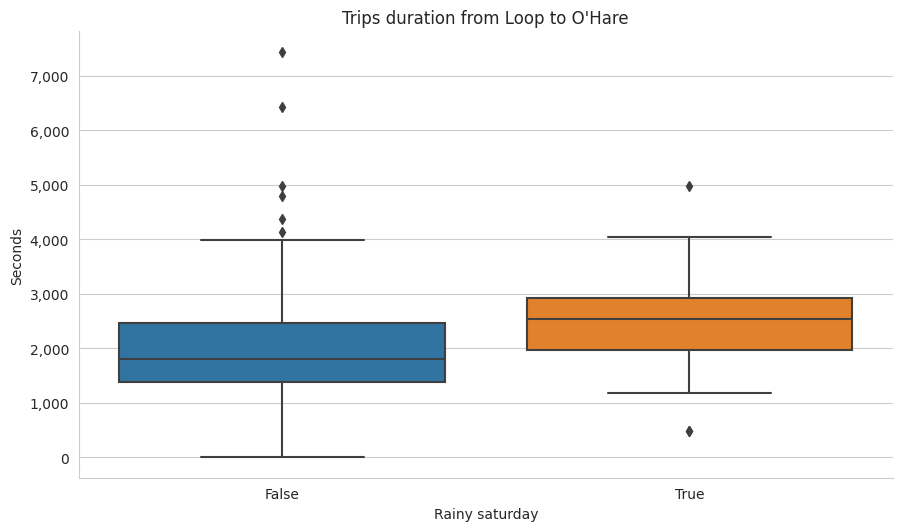

In [23]:
# Gráfica de los 10 principales barrios
g=sns.catplot(data = df, y = 'duration_seconds', x= 'lluvioso',kind = 'box', aspect = 16/9)
g.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.title("Trips duration from Loop to O'Hare")
plt.xlabel("Rainy saturday")
plt.ylabel("Seconds")

plt.show()


In [24]:
# Realizar la prueba

alpha = 0.05  # el nivel de significancia estadística crítica
# si el valor p es menor que alpha, rechazamos la hipótesis

results = st.ttest_ind(df_lluvioso['duration_seconds'], df_no_lluvioso['duration_seconds'], equal_var = False) # realizar una prueba

print('valor p: ', results.pvalue) # extraer el valor p

if results.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  6.738994326108734e-12
Rechazamos la hipótesis nula


Se ha **rechazado** la hipótesis nula. Es muy poco probable obtener estos datos si realmente en promedio el tiempo de traslado es el mismo si llueve o no.